# Exercises XP Ninja - Image Compression with K-Means and PCA

## What you will learn
- Image compression with K-Means on RGB pixels
- Dimensionality reduction with PCA

## What you will create
- Compressed image with reduced color palette
- PCA projection and recovery plots


### Provided helpers
Use these functions for K-Means. Do not modify them.

In [ ]:
import numpy as np

def init_centroids(X, K, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    m = X.shape[0]
    idx = rng.choice(m, size=K, replace=False)
    return X[idx].astype(float)

def find_closest_centroids(X, centroids):
    diffs = X[:, None, :] - centroids[None, :, :]
    d2 = np.sum(diffs * diffs, axis=2)
    return np.argmin(d2, axis=1)

def compute_centroids(X, idx, K, rng=None):
    m, n = X.shape
    C = np.zeros((K, n), dtype=float)
    rng = np.random.default_rng() if rng is None else rng
    for k in range(K):
        pts = X[idx == k]
        if pts.size == 0:
            C[k] = X[rng.integers(0, m)]
        else:
            C[k] = pts.mean(axis=0)
    return C

def run_k_means(X, init_C, max_iters=10, rng=None):
    K = init_C.shape[0]
    C = init_C.copy().astype(float)
    history = [C.copy()]
    idx = None
    for _ in range(max_iters):
        idx = find_closest_centroids(X, C)
        C = compute_centroids(X, idx, K, rng=rng)
        history.append(C.copy())
    return C, idx, history

## Task 1 - Load and preprocess image from `bird_small.mat`
- Load with `scipy.io.loadmat`
- Normalize to [0,1] by dividing by 255
- Reshape image to a 2D array of RGB pixels shape (m, 3)

Image shape: (128, 128, 3) Pixels shape: (16384, 3)


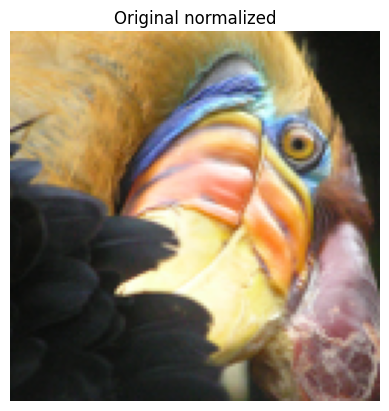

In [4]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np

mat = loadmat('bird_small.mat')
# The variable is usually 'A' with shape (H, W, 3)
A = mat.get('A', None)
if A is None:
    for k in mat.keys():
        if isinstance(mat[k], np.ndarray) and mat[k].ndim == 3 and mat[k].shape[2] == 3:
            A = mat[k]; break
if A is None:
    raise ValueError('Could not find 3D RGB array in bird_small.mat')

# Normalize to [0,1]
A_norm = A / 255.0
# Reshape to 2D array of pixels (m, 3)
H, W, C = A_norm.shape
X_img = A_norm.reshape(H * W, C)

print('Image shape:', A.shape, 'Pixels shape:', X_img.shape)

plt.imshow(A_norm); plt.title('Original normalized'); plt.axis('off'); plt.show()

## Task 2 - K-Means image compression
- Choose K and max_iters
- Initialize centroids randomly with `init_centroids`
- Run K-Means and map each pixel to its centroid color
- Reshape back to image and visualize

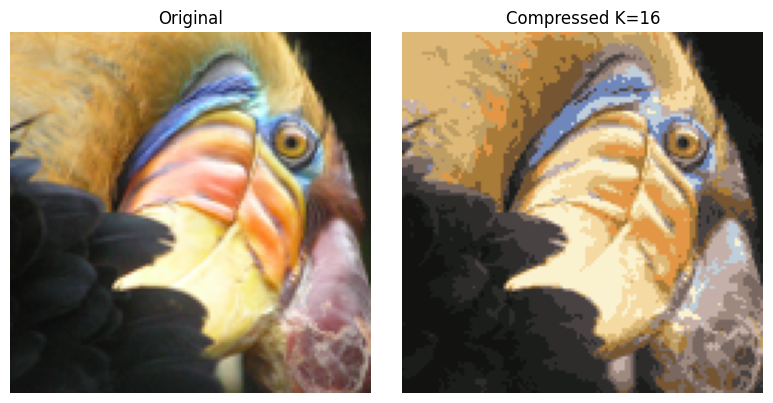

Original colors: 16384  →  Palette size: 16


In [5]:
K = 16    # number of colors in compressed palette
ITERS = 10
rng = np.random.default_rng(0)
C0 = init_centroids(X_img, K, rng)
C_final, idx, hist = run_k_means(X_img, C0, max_iters=ITERS, rng=rng)

# Replace each pixel with its centroid color
X_comp = C_final[idx]

# Reshape back to image dimensions
A_comp = X_comp.reshape(H, W, 3)
A_comp = np.clip(A_comp, 0, 1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(A_norm); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(A_comp); plt.title(f'Compressed K={K}'); plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Original colors: {H*W}  →  Palette size: {K}')

## Task 3 - PCA on `ex7data1.mat`
- Load `X` from the file. If the file is missing, the cell will create a synthetic 2D dataset so you can proceed
- Feature normalize: subtract mean and divide by std
- Compute covariance matrix and do SVD with `np.linalg.svd`
- Project onto first principal component and recover back
- Plot original, projection line, and recovered points

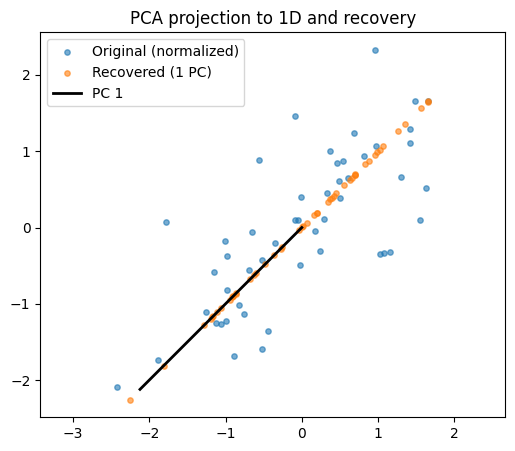

Explained variance by PC1: 86.8%


In [7]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt

try:
    X = loadmat('ex7data1.mat').get('X', None)
    if X is None:
        raise FileNotFoundError('X not found in mat file')
except Exception:
    rng = np.random.default_rng(0)
    t = rng.normal(size=300)
    X = np.c_[t, 0.4*t + rng.normal(scale=0.2, size=t.shape)]

m, n = X.shape

# Feature normalize
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X_norm = (X - mu) / sigma

# Covariance matrix and SVD
Sigma = (1 / m) * X_norm.T @ X_norm
U, S, Vt = np.linalg.svd(Sigma)

# Project onto first principal component and recover
U1 = U[:, :1]           # shape (n, 1)
Z = X_norm @ U1         # shape (m, 1)  — 1D projections
X_rec = Z @ U1.T        # shape (m, n)  — reconstructed in original space

plt.figure(figsize=(6, 5))
plt.scatter(X_norm[:, 0], X_norm[:, 1], s=15, alpha=0.6, label='Original (normalized)')
plt.scatter(X_rec[:, 0], X_rec[:, 1], s=15, alpha=0.6, label='Recovered (1 PC)')
# Draw the first principal component direction
scale = 3
plt.plot([0, scale * U[0, 0]], [0, scale * U[1, 0]], 'k-', lw=2, label='PC 1')
plt.title('PCA projection to 1D and recovery')
plt.legend(); plt.axis('equal'); plt.show()

print(f'Explained variance by PC1: {S[0]/S.sum()*100:.1f}%')

## Task 4 - Recover and visualize
- Show the K-Means compressed image alongside the original
- Show the PCA recovered dataset alongside the original normalized points
- Highlight how much information is lost/retained in each case

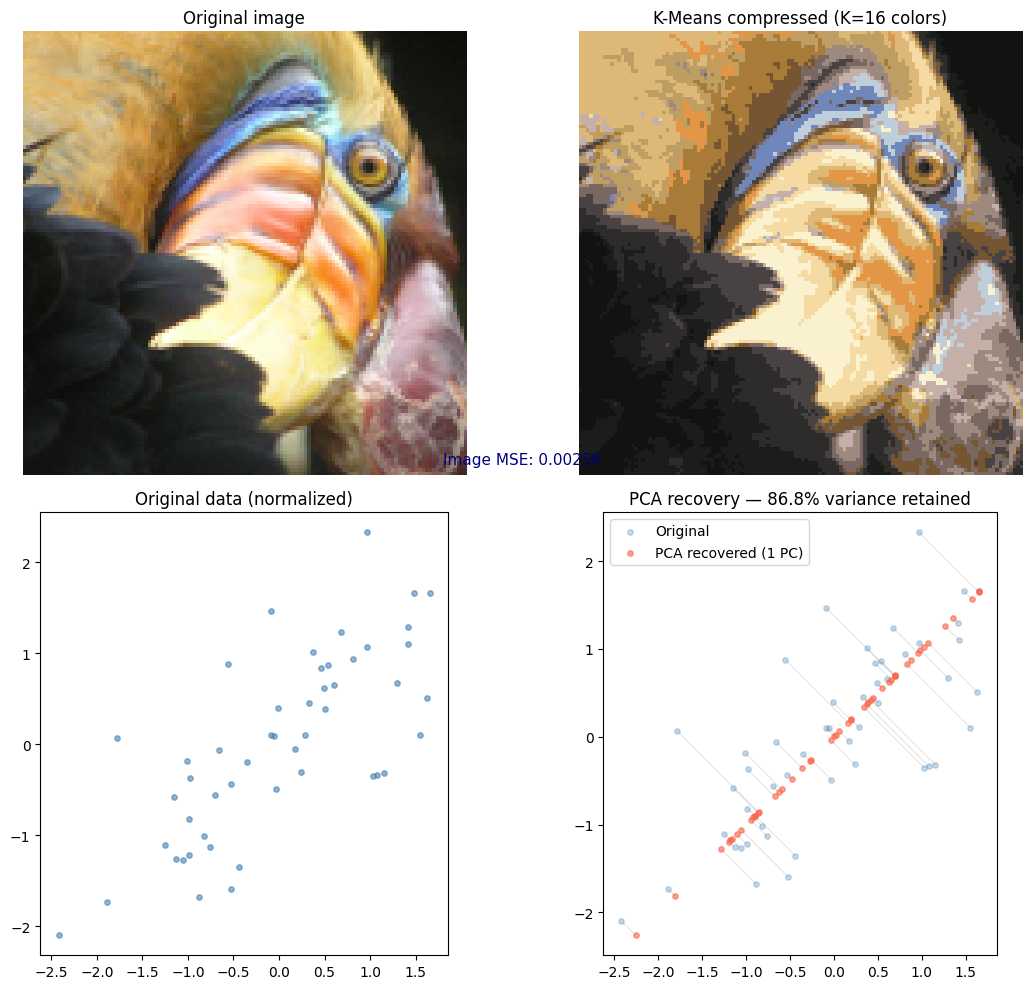

K-Means image MSE : 0.00256
PCA reconstruction MSE : 0.13223
Variance retained by PC1: 86.8%


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- Row 1: K-Means image compression ---
axes[0, 0].imshow(A_norm)
axes[0, 0].set_title('Original image')
axes[0, 0].axis('off')

axes[0, 1].imshow(A_comp)
axes[0, 1].set_title(f'K-Means compressed (K={K} colors)')
axes[0, 1].axis('off')

# Compute and show pixel-level reconstruction error
mse_img = np.mean((A_norm - A_comp) ** 2)
fig.text(0.5, 0.53, f'Image MSE: {mse_img:.5f}', ha='center', fontsize=11, color='navy')

# --- Row 2: PCA recovery ---
axes[1, 0].scatter(X_norm[:, 0], X_norm[:, 1], s=15, alpha=0.6, color='steelblue')
axes[1, 0].set_title('Original data (normalized)')
axes[1, 0].set_aspect('equal')

axes[1, 1].scatter(X_norm[:, 0], X_norm[:, 1], s=15, alpha=0.3, color='steelblue', label='Original')
axes[1, 1].scatter(X_rec[:, 0], X_rec[:, 1], s=15, alpha=0.6, color='tomato', label='PCA recovered (1 PC)')
# Draw lines connecting each point to its projection to show the loss
for orig, rec in zip(X_norm, X_rec):
    axes[1, 1].plot([orig[0], rec[0]], [orig[1], rec[1]], 'gray', lw=0.4, alpha=0.4)
axes[1, 1].set_title(f'PCA recovery — {S[0]/S.sum()*100:.1f}% variance retained')
axes[1, 1].legend()
axes[1, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(f'K-Means image MSE : {mse_img:.5f}')
print(f'PCA reconstruction MSE : {np.mean((X_norm - X_rec)**2):.5f}')
print(f'Variance retained by PC1: {S[0]/S.sum()*100:.1f}%')